In [91]:
import numpy as np
import pandas as pd
import matplotlib as mpl
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import umap
import seaborn as sns
import matplotlib.pyplot as plt
from nonconformist.base import BaseModelAdapter
from nonconformist.nc import MarginErrFunc
from nonconformist.cp import TcpClassifier 
from sklearn.base import BaseEstimator

# 300 dpi
mpl.rcParams['figure.dpi'] = 300
# settings to display more columns and rows
pd.set_option("max_colwidth", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [46]:
# Load the data
filtered_df = '/home/jovyan/share/data/analyses/sofia/kinase378-vt1/CellProfiler/U2OS/df_test_pred.csv'
df = pd.read_csv(f'{filtered_df}', sep=';', index_col=0)

/tmp/ipykernel_505706/1789402409.py:3: DtypeWarning: Columns (1447) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{filtered_df}', sep=';', index_col=0)


In [47]:
df.head()   

,AreaShape_Area_nuclei,AreaShape_BoundingBoxArea_nuclei,AreaShape_BoundingBoxMaximum_X_nuclei,AreaShape_BoundingBoxMaximum_Y_nuclei,AreaShape_BoundingBoxMinimum_X_nuclei,AreaShape_BoundingBoxMinimum_Y_nuclei,AreaShape_Center_X_nuclei,AreaShape_Center_Y_nuclei,AreaShape_Compactness_nuclei,AreaShape_ConvexArea_nuclei,AreaShape_Eccentricity_nuclei,AreaShape_EquivalentDiameter_nuclei,AreaShape_Extent_nuclei,AreaShape_FormFactor_nuclei,AreaShape_MajorAxisLength_nuclei,AreaShape_MaxFeretDiameter_nuclei,AreaShape_MaximumRadius_nuclei,AreaShape_MeanRadius_nuclei,AreaShape_MedianRadius_nuclei,AreaShape_MinFeretDiameter_nuclei,AreaShape_MinorAxisLength_nuclei,AreaShape_Orientation_nuclei,AreaShape_Perimeter_nuclei,AreaShape_Solidity_nuclei,AreaShape_Zernike_0_0_nuclei,AreaShape_Zernike_1_1_nuclei,AreaShape_Zernike_2_0_nuclei,AreaShape_Zernike_2_2_nuclei,AreaShape_Zernike_4_0_nuclei,Children_cytoplasm_Count_nuclei,Correlation_Correlation_illumCONC_illumHOECHST_nuclei,Correlation_Correlation_illumCONC_illumMITO_nuclei,Correlation_Correlation_illumCONC_illumPHAandWGA_nuclei,Correlation_Correlation_illumCONC_illumSYTO_nuclei,Correlation_Correlation_illumHOECHST_illumMITO_nuclei,Correlation_Correlation_illumHOECHST_illumPHAandWGA_nuclei,Correlation_Correlation_illumHOECHST_illumSYTO_nuclei,Correlation_Correlation_illumMITO_illumPHAandWGA_nuclei,Correlation_Correlation_illumMITO_illumSYTO_nuclei,Correlation_Correlation_illumPHAandWGA_illumSYTO_nuclei,Correlation_K_illumCONC_illumHOECHST_nuclei,Correlation_K_illumCONC_illumMITO_nuclei,Correlation_K_illumCONC_illumPHAandWGA_nuclei,Correlation_K_illumCONC_illumSYTO_nuclei,Correlation_K_illumHOECHST_illumCONC_nuclei,Correlation_K_illumHOECHST_illumMITO_nuclei,Correlation_K_illumHOECHST_illumPHAandWGA_nuclei,Correlation_K_illumHOECHST_illumSYTO_nuclei,Correlation_K_illumMITO_illumCONC_nuclei,Correlation_K_illumMITO_illumHOECHST_nuclei,...,RadialDistribution_ZernikePhase_illumPHAandWGA_9_7_cytoplasm,RadialDistribution_ZernikePhase_illumPHAandWGA_9_9_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_1_1_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_2_2_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_3_1_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_3_3_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_4_0_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_4_2_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_4_4_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_5_1_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_5_3_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_5_5_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_6_0_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_6_2_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_6_4_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_6_6_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_7_1_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_7_3_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_7_5_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_7_7_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_8_0_cytoplasm,RadialDistribution_ZernikePhase_illumSYTO_8_2_cytoplasm,Metadata_Barcode,Metadata_Well,Metadata_Site,Count_nuclei,compound_id,cmpd_conc,cmpd_name,Family,therapeutic_class_2023,ImageID,ReplicateGroup,Replicate,higher_than_one_grit,grit,cbkid,compound_name,protein_kinase_inhibitor,receptor_family,target,inhibitory_effect,seconday_target,tertiary_target,all_targets,induces_effect,pathway,selectivity_against_others,kinase_assay,notes
18,-2.387693,-3.163362,1.646694,-0.329097,1.680658,-0.227255,1.666785,-0.278014,-2.996112,-2.502567,-5.602493,-2.699048,4.300221,3.366809,-4.689410,-4.639899,0.183057,-0.626536,-1.076003,-0.088936,0.185247,0.693300,-3.537965,1.474128,4.939376,-0.322307,-3.116766,-4.220951,7.283333,-3.717586,1.720820,2.555016,0.506167,2.070357,1.957861,2.230232,1.260773,2.098796,3.549615,2.868006,1.139542,0.397138,-1.230998,0.433247,-1.009092,-0.381105,-1.879905,-0.816302,-0.463199,0.095310,.

In [105]:
# Prepare the features (X) and target (y)
X = df.drop(columns=['Family','ReplicateGroup', 'cmpd_conc'] + df.columns[-28:].tolist())  # Features (excluding metadata and target)
y = df['Family']  # Target (Family column)
# Group by 'Family' and collect unique compound IDs
group_map = df.groupby('Family')['compound_id'].unique().apply(list).to_dict()

# Display the result
group_map

In [111]:
# Group by 'Family' and collect unique compound IDs
group_map = df.groupby('Family')['compound_id'].unique().apply(list).to_dict()

# Display the result
group_map

{'AUR': ['CBK288286G',
  'CBK290482',
  'CBK277972',
  'CBK277955',
  'CBK288285',
  'CBK288288',
  'CBK290772',
  'CBK288281',
  'CBK290801',
  'CBK288282',
  'CBK288349',
  'CBK278064',
  'CBK293886',
  'CBK288284'],
 'Akt': ['CBK201383',
  'CBK277971C',
  'CBK290756',
  'CBK288338',
  'CBK278103',
  'CBK293872',
  'CBK293866',
  'CBK290956',
  'CBK290457C'],
 'CAMKL': ['CBK288348',
  'CBK278040',
  'CBK293853',
  'CBK277954',
  'CBK293882',
  'CBK290745'],
 'CDK': ['CBK277936',
  'CBK278001',
  'CBK288278',
  'CBK288280',
  'CBK277922C',
  'CBK288279C',
  'CBK290797',
  'CBK288335',
  'CBK290823',
  'CBK277941C',
  'CBK290859',
  'CBK278081',
  'CBK290752',
  'CBK290998',
  'CBK293881',
  'CBK293858C',
  'CBK293860G',
  'CBK293896'],
 'DMPK': ['CBK290556', 'CBK041232C', 'CBK290561', 'CBK293862'],
 'PIKK': ['CBK288312',
  'CBK277993',
  'CBK277967',
  'CBK277956',
  'CBK041801',
  'CBK288329',
  'CBK278051',
  'CBK288307',
  'CBK288313',
  'CBK288346',
  'CBK277965',
  'CBK288341',
 

In [120]:
# 2. Define how many compounds you want to keep in the test/validation set from each family
n_test_val = 1  # You can adjust this number (e.g., 1 compound per family, or 2 compounds per family)

# 3. Initialize dictionaries to hold split IDs
train_map = {}
val_map = {}
test_map = {}

# 4. Loop through each family and split the compounds
for family, compounds in group_map.items():
    # Split the compounds of each family into train, val, and test sets
    # First, shuffle the list of compounds for randomness
    np.random.shuffle(compounds)
    
    # Select compounds for the test/validation sets
    test_val_compounds = compounds[:n_test_val]  # Use the first n_test_val compounds for test/validation
    
    # The remaining compounds will go to the training set
    train_compounds = compounds[n_test_val:]
    
    # Assign these to the respective maps
    train_map[family] = train_compounds
    test_map[family] = test_val_compounds  # You can later split between validation and test
    val_map[family] = test_val_compounds  # Temporary, splitting later if needed

# Print the mappings for train, validation, and test sets
print("Train map size:", {key: len(value) for key, value in train_map.items()})
print("Validation map size:", {key: len(value) for key, value in val_map.items()})
print("Test map size:", {key: len(value) for key, value in test_map.items()})

# Initialize the lists with None to match the length of the DataFrame
train_families = [None] * len(df)
val_families = [None] * len(df)
test_families = [None] * len(df)


# Loop through each row in the DataFrame to assign family to train, validation, or test
for index, row in df.iterrows():
    family = row['Family']
    compound = row['compound_id']
    
    # Check in which split the compound should be
    if compound in train_map.get(family, []):
        train_families[df.index.get_loc(index)] = family
    elif compound in val_map.get(family, []):
        val_families[df.index.get_loc(index)] = family
    elif compound in test_map.get(family, []):
        test_families[df.index.get_loc(index)] = family


# Assign these lists as new columns to the DataFrame
df['train_family'] = train_families
df['val_family'] = val_families
df['test_family'] = test_families

# Check if the columns are added correctly
print(df[['Family', 'train_family', 'val_family', 'test_family']].head())

# Check the distribution of families in each split again
print("\nTraining set family distribution:\n", df['train_family'].value_counts())
print("\nValidation set family distribution:\n", df['val_family'].value_counts())
print("\nTest set family distribution:\n", df['test_family'].value_counts())
# 8. Create boolean masks for splitting the data
train_mask = df['train_family'].notna()
val_mask = df['val_family'].notna()
test_mask = df['test_family'].notna()

# 9. Split the data based on these masks
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# 10. Check the distribution of families in each split
print("Training set family distribution:\n", y_train.value_counts())
print("\nValidation set family distribution:\n", y_val.value_counts())
print("\nTest set family distribution:\n", y_test.value_counts())

Train map size: {'AUR': 13, 'Akt': 8, 'CAMKL': 5, 'CDK': 17, 'DMPK': 3, 'PIKK': 21, 'PLK': 6, 'Src': 4}
Validation map size: {'AUR': 1, 'Akt': 1, 'CAMKL': 1, 'CDK': 1, 'DMPK': 1, 'PIKK': 1, 'PLK': 1, 'Src': 1}
Test map size: {'AUR': 1, 'Akt': 1, 'CAMKL': 1, 'CDK': 1, 'DMPK': 1, 'PIKK': 1, 'PLK': 1, 'Src': 1}
   Family train_family val_family test_family
18   DMPK         DMPK       None        None
19   DMPK         DMPK       None        None
20   DMPK         DMPK       None        None
21   DMPK         DMPK       None        None
22   DMPK         DMPK       None        None

Training set family distribution:
 train_family
PIKK     658
CDK      514
AUR      419
Akt      231
PLK      185
CAMKL    137
Src      126
DMPK     108
Name: count, dtype: int64

Validation set family distribution:
 val_family
CDK      36
PIKK     36
CAMKL    36
DMPK     36
Src      35
PLK      18
AUR      18
Akt      18
Name: count, dtype: int64

Test set family distribution:
 Series([], Name: count, dtype: i

In [147]:
# 4. Split the data into training, validation, and test sets 
"""	Keeping 30% aside initially ensures the model doesn’t see that data during training, helping avoid overfitting. """

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% train, 30% temp (15 validation, 15 test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # Split temp into 50% validation and 50% test


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


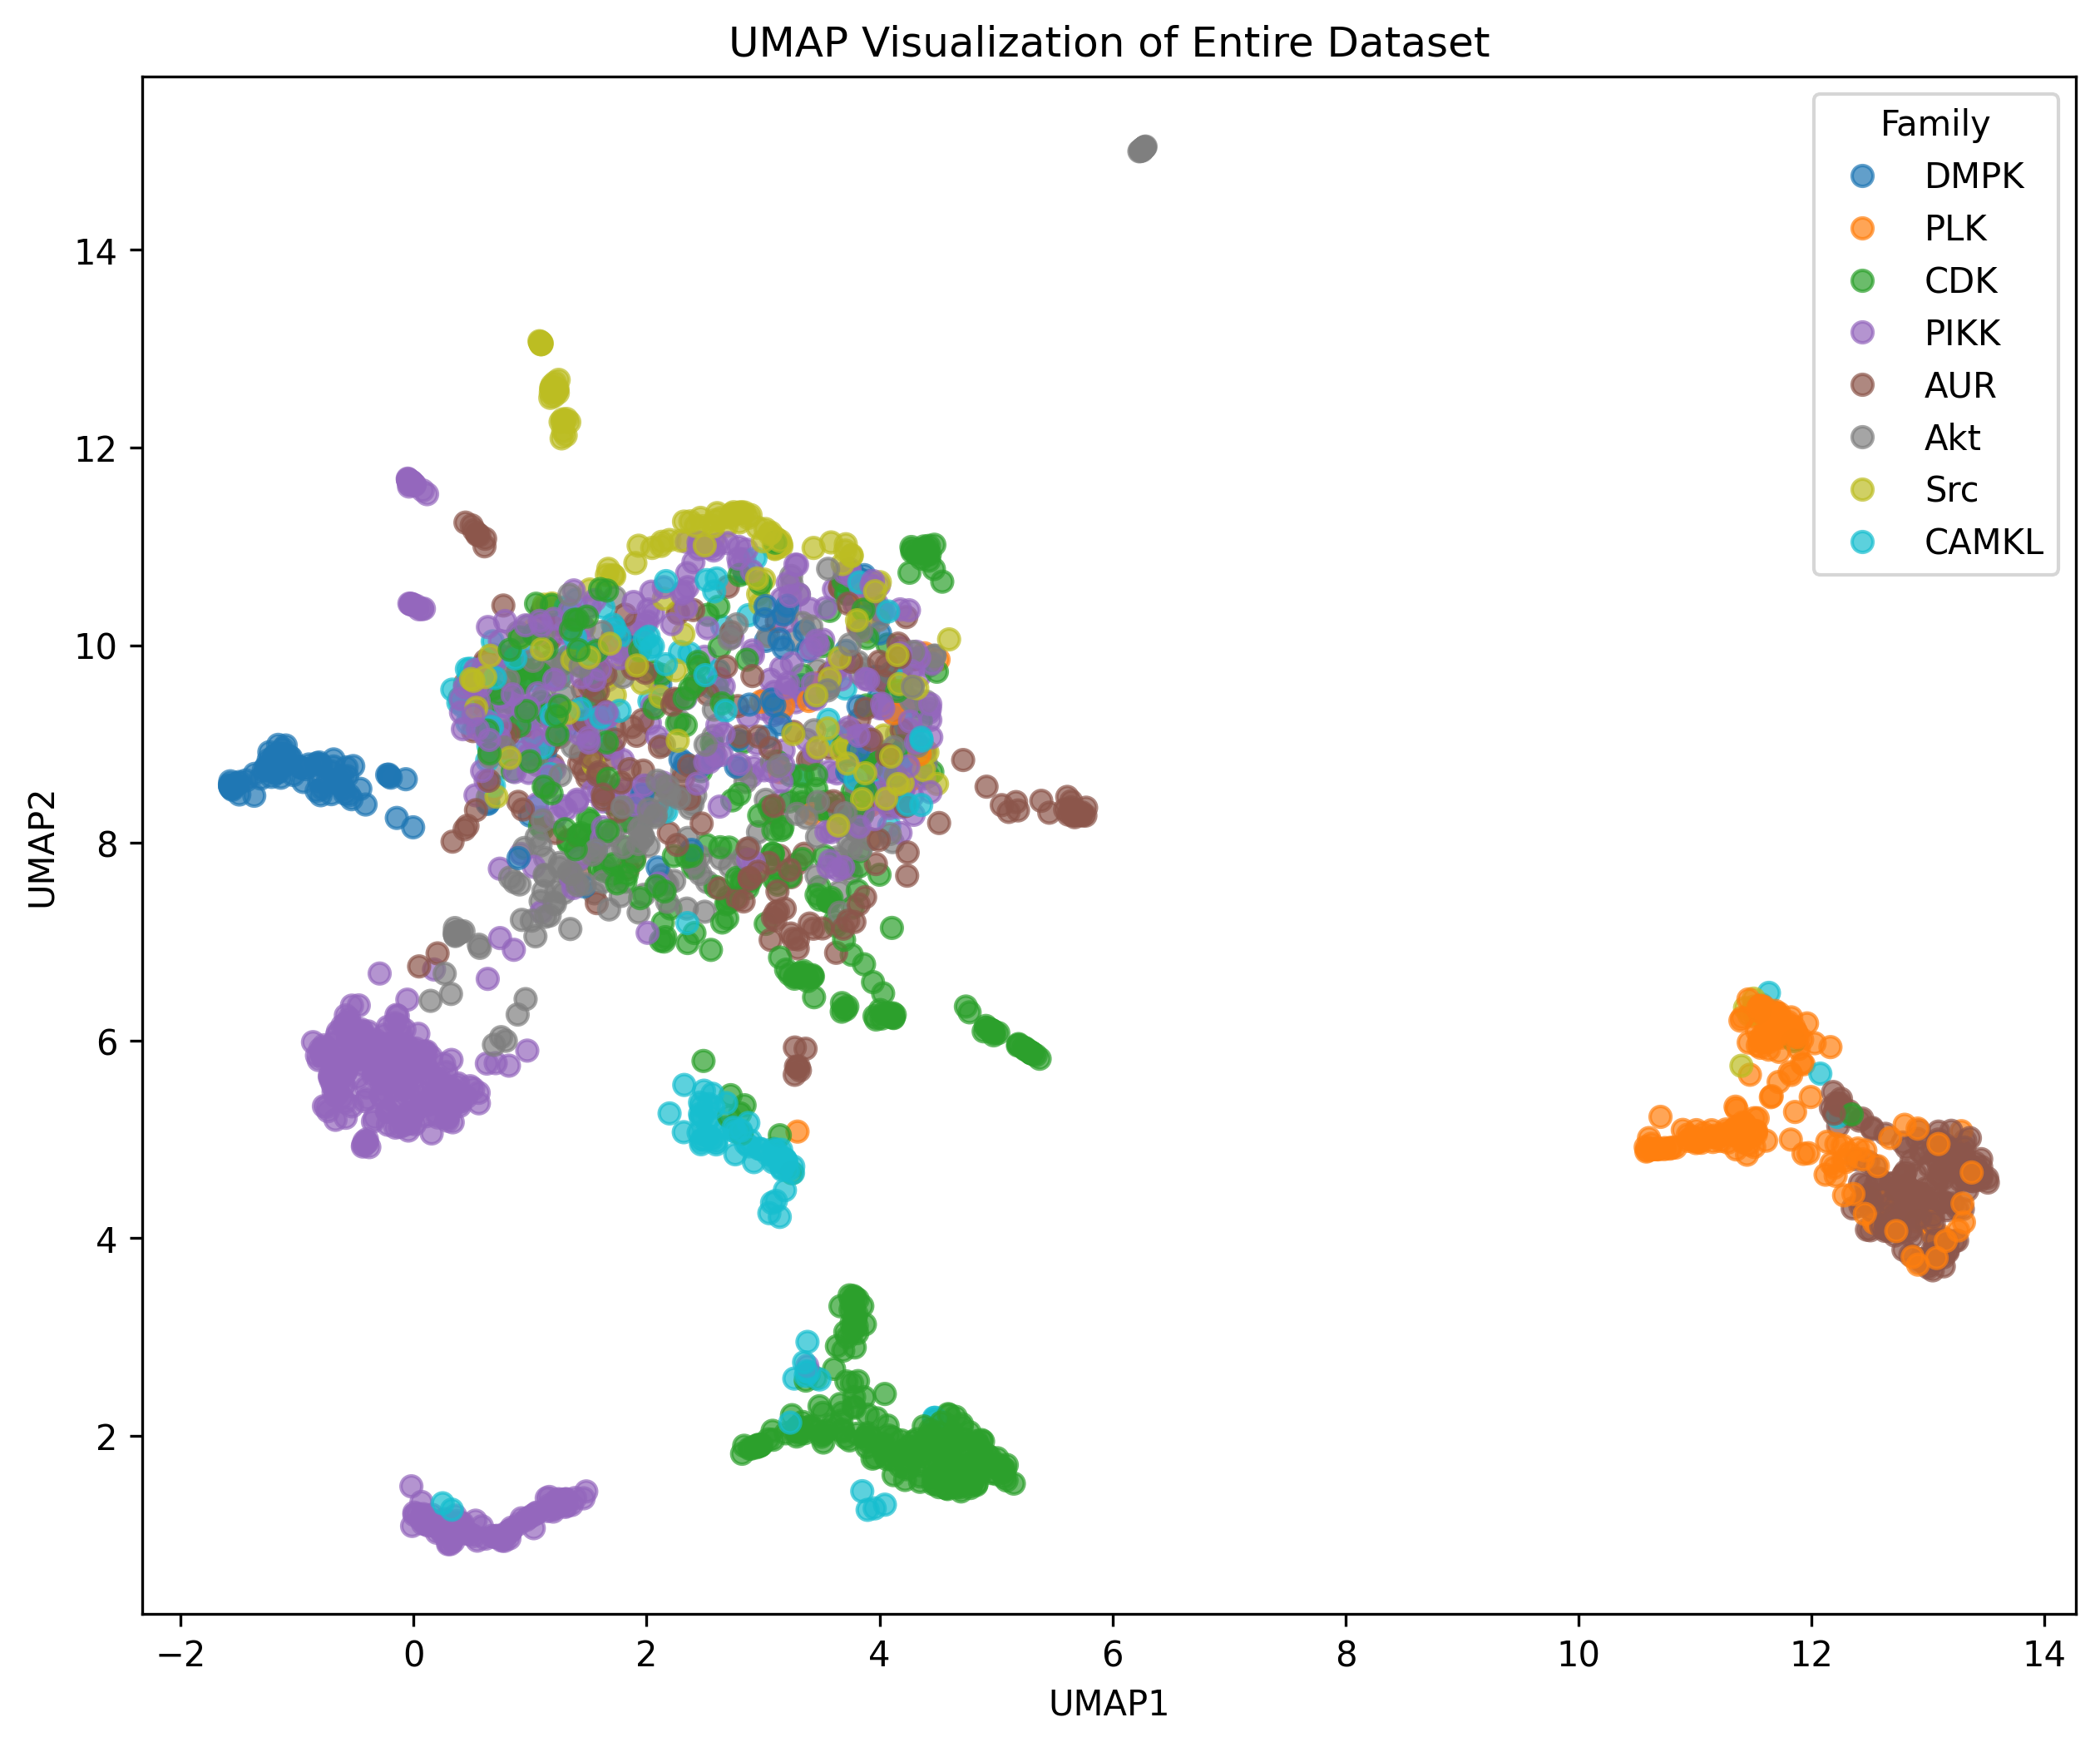

In [122]:
import umap
import matplotlib.pyplot as plt
import pandas as pd

# Assuming X and y are already defined
# Reduce dimensionality with UMAP
umap_model = umap.UMAP(random_state=42)
X_umap = umap_model.fit_transform(X)  # Fit and transform the entire dataset

# Create a DataFrame for visualization
umap_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
umap_df['Family'] = y.values  # Add the target labels

# Plot the data
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_df['UMAP1'], 
    umap_df['UMAP2'], 
    c=umap_df['Family'].map(dict(zip(y.unique(), range(len(y.unique()))))),
    alpha=0.7, 
    cmap='tab10'
)
#plt.colorbar(scatter, ticks=range(len(y.unique())), label='Family')
plt.title('UMAP Visualization of Entire Dataset')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
# Add the legend with Family names
handles, labels = scatter.legend_elements()  # Get legend elements
plt.legend(handles, y.unique(), title="Family", loc='upper right')
plt.show()

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


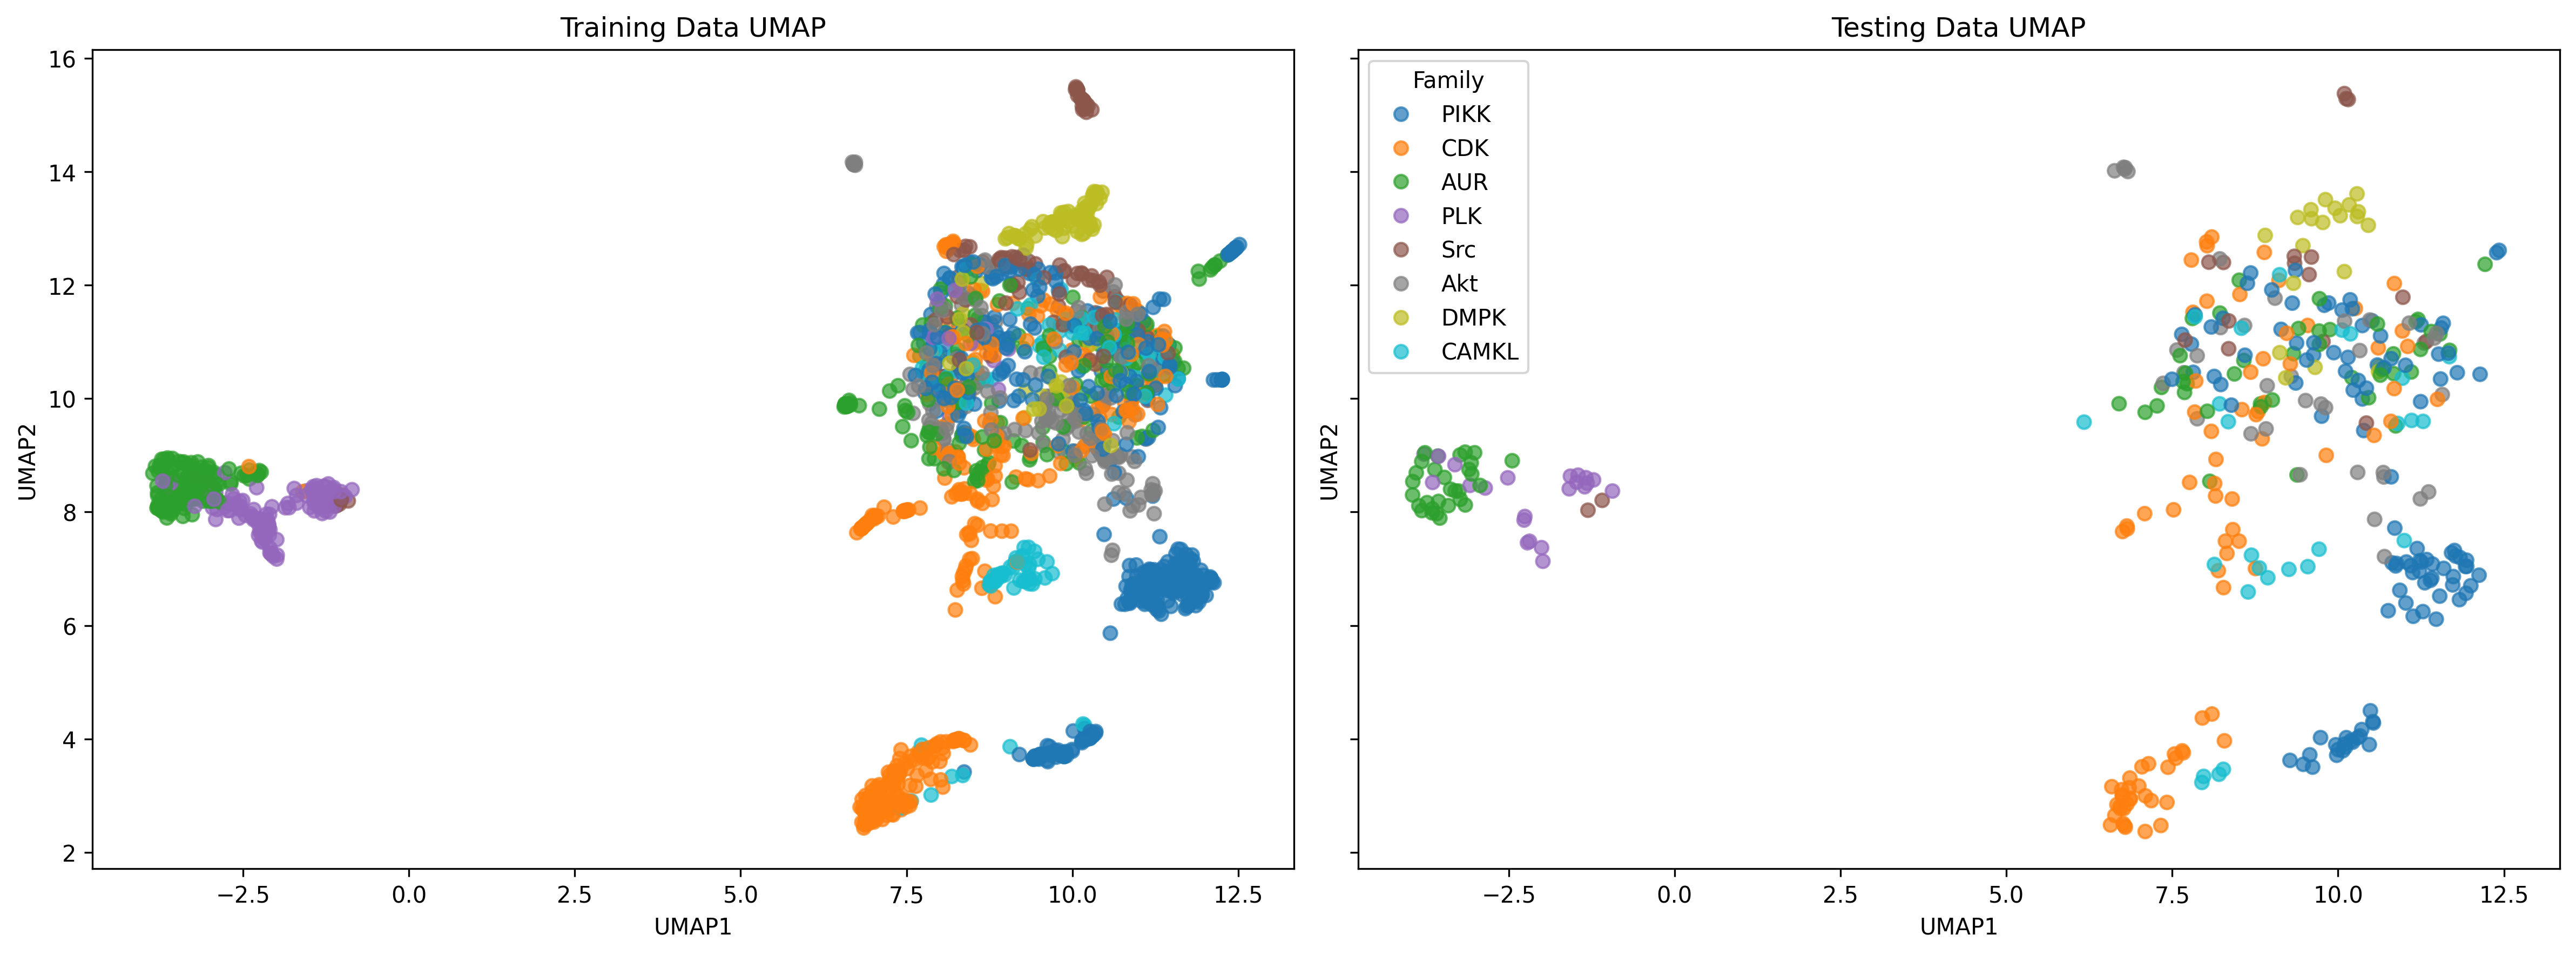

In [139]:
import pandas as pd
from sklearn.model_selection import train_test_split
import umap
import matplotlib.pyplot as plt

# Assuming X_train, X_test, y_train, y_test are already defined
# Reduce dimensionality with UMAP
umap_model = umap.UMAP(random_state=42)
X_train_umap = umap_model.fit_transform(X_train)  # Fit and transform training data
X_test_umap = umap_model.transform(X_test)       # Transform test data using the same UMAP model

# Create a DataFrame for visualization
train_df = pd.DataFrame(X_train_umap, columns=['UMAP1', 'UMAP2'])
train_df['Family'] = y_train.values  # Add the target labels

test_df = pd.DataFrame(X_test_umap, columns=['UMAP1', 'UMAP2'])
test_df['Family'] = y_test.values  # Add the target labels

# Create a common color map for the labels
unique_labels = y_train.unique()  # Use y_train's unique labels for consistency
label_map = dict(zip(unique_labels, range(len(unique_labels))))  # Map labels to integers
cmap = plt.get_cmap('tab10')  # Use a fixed colormap

# Plot the training and testing data
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

# Training data
scatter_train = axes[0].scatter(
    train_df['UMAP1'], train_df['UMAP2'],
    c=train_df['Family'].map(label_map), alpha=0.7, cmap=cmap
)
axes[0].set_title('Training Data UMAP')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')

# Testing data
scatter_test = axes[1].scatter(
    test_df['UMAP1'], test_df['UMAP2'],
    c=test_df['Family'].map(label_map), alpha=0.7, cmap=cmap
)
axes[1].set_title('Testing Data UMAP')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')

# Create legends for both plots
handles, labels = scatter_train.legend_elements()  # Get legend elements for both plots

# Add the legend to the figure
plt.legend(handles, unique_labels, title="Family", loc='upper left')

plt.tight_layout()
plt.show()

In [129]:
# Experiment with different kernels
"""try different SVM kernels (linear, poly, rbf, and sigmoid) and evaluate the performance using 5-fold cross-validation, also prints the average accuracy."""
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
accuracies = []

# - uses cross-validation to estimate how well the model will generalize to new, unseen data.
for kernel in kernels:
    model = SVC(kernel=kernel, probability=True)  # Enable probability for predict_proba
    cv_accuracies = cross_val_score(model, X_train, y_train, cv=5)  # 5-fold cross-validation - The model is trained 5 times, each time using 4 folds for training and 1 fold for validation.
    accuracies.append((kernel, np.mean(cv_accuracies)))

# Print the results - 	The average performance (accuracy) across these 5 tests is computed to estimate the model’s effectiveness in predicting unseen data.
for kernel, accuracy in accuracies:
    print(f"Kernel: {kernel}, Cross-Validation Accuracy: {accuracy}")


Kernel: linear, Cross-Validation Accuracy: 0.6902028594954712
Kernel: poly, Cross-Validation Accuracy: 0.5413294408264091
Kernel: rbf, Cross-Validation Accuracy: 0.7296429373456097
Kernel: sigmoid, Cross-Validation Accuracy: 0.465241410285201


In [130]:

# Apply GridSearchCV for hyperparameter tuning (RBF kernel example)
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
model = SVC(kernel='rbf')  # RBF Kernel

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best hyperparameters for RBF kernel: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

Best hyperparameters for RBF kernel: {'C': 10, 'gamma': 'scale'}
Best score: 0.7586346283404446


In [131]:
# Train the model using the best kernel (e.g., RBF) with the best parameters
best_model = SVC(kernel='rbf', C=grid_search.best_params_['C'], gamma=grid_search.best_params_['gamma'], probability=True)
best_model.fit(X_train, y_train)

SVC(C=10, probability=True)

In [132]:

# Evaluate the model on the validation set - The validation set (X_val, y_val) is used to evaluate the model’s performance after hyperparameter tuning (UNSEEN DATA during training).
y_val_pred = best_model.predict(X_val)
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))

# Evaluate on the test set 
y_test_pred = best_model.predict(X_test)
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))


Validation Classification Report:
              precision    recall  f1-score   support

         AUR       0.81      0.79      0.80        66
         Akt       0.61      0.71      0.66        31
       CAMKL       0.73      0.59      0.65        27
         CDK       0.87      0.87      0.87        78
        DMPK       1.00      0.76      0.86        21
        PIKK       0.74      0.80      0.77       112
         PLK       0.88      0.95      0.91        37
         Src       0.80      0.60      0.69        20

    accuracy                           0.79       392
   macro avg       0.81      0.76      0.78       392
weighted avg       0.80      0.79      0.79       392

Test Classification Report:
              precision    recall  f1-score   support

         AUR       0.83      0.67      0.74        72
         Akt       0.65      0.59      0.62        37
       CAMKL       0.75      0.46      0.57        26
         CDK       0.82      0.87      0.84        83
        DMPK    

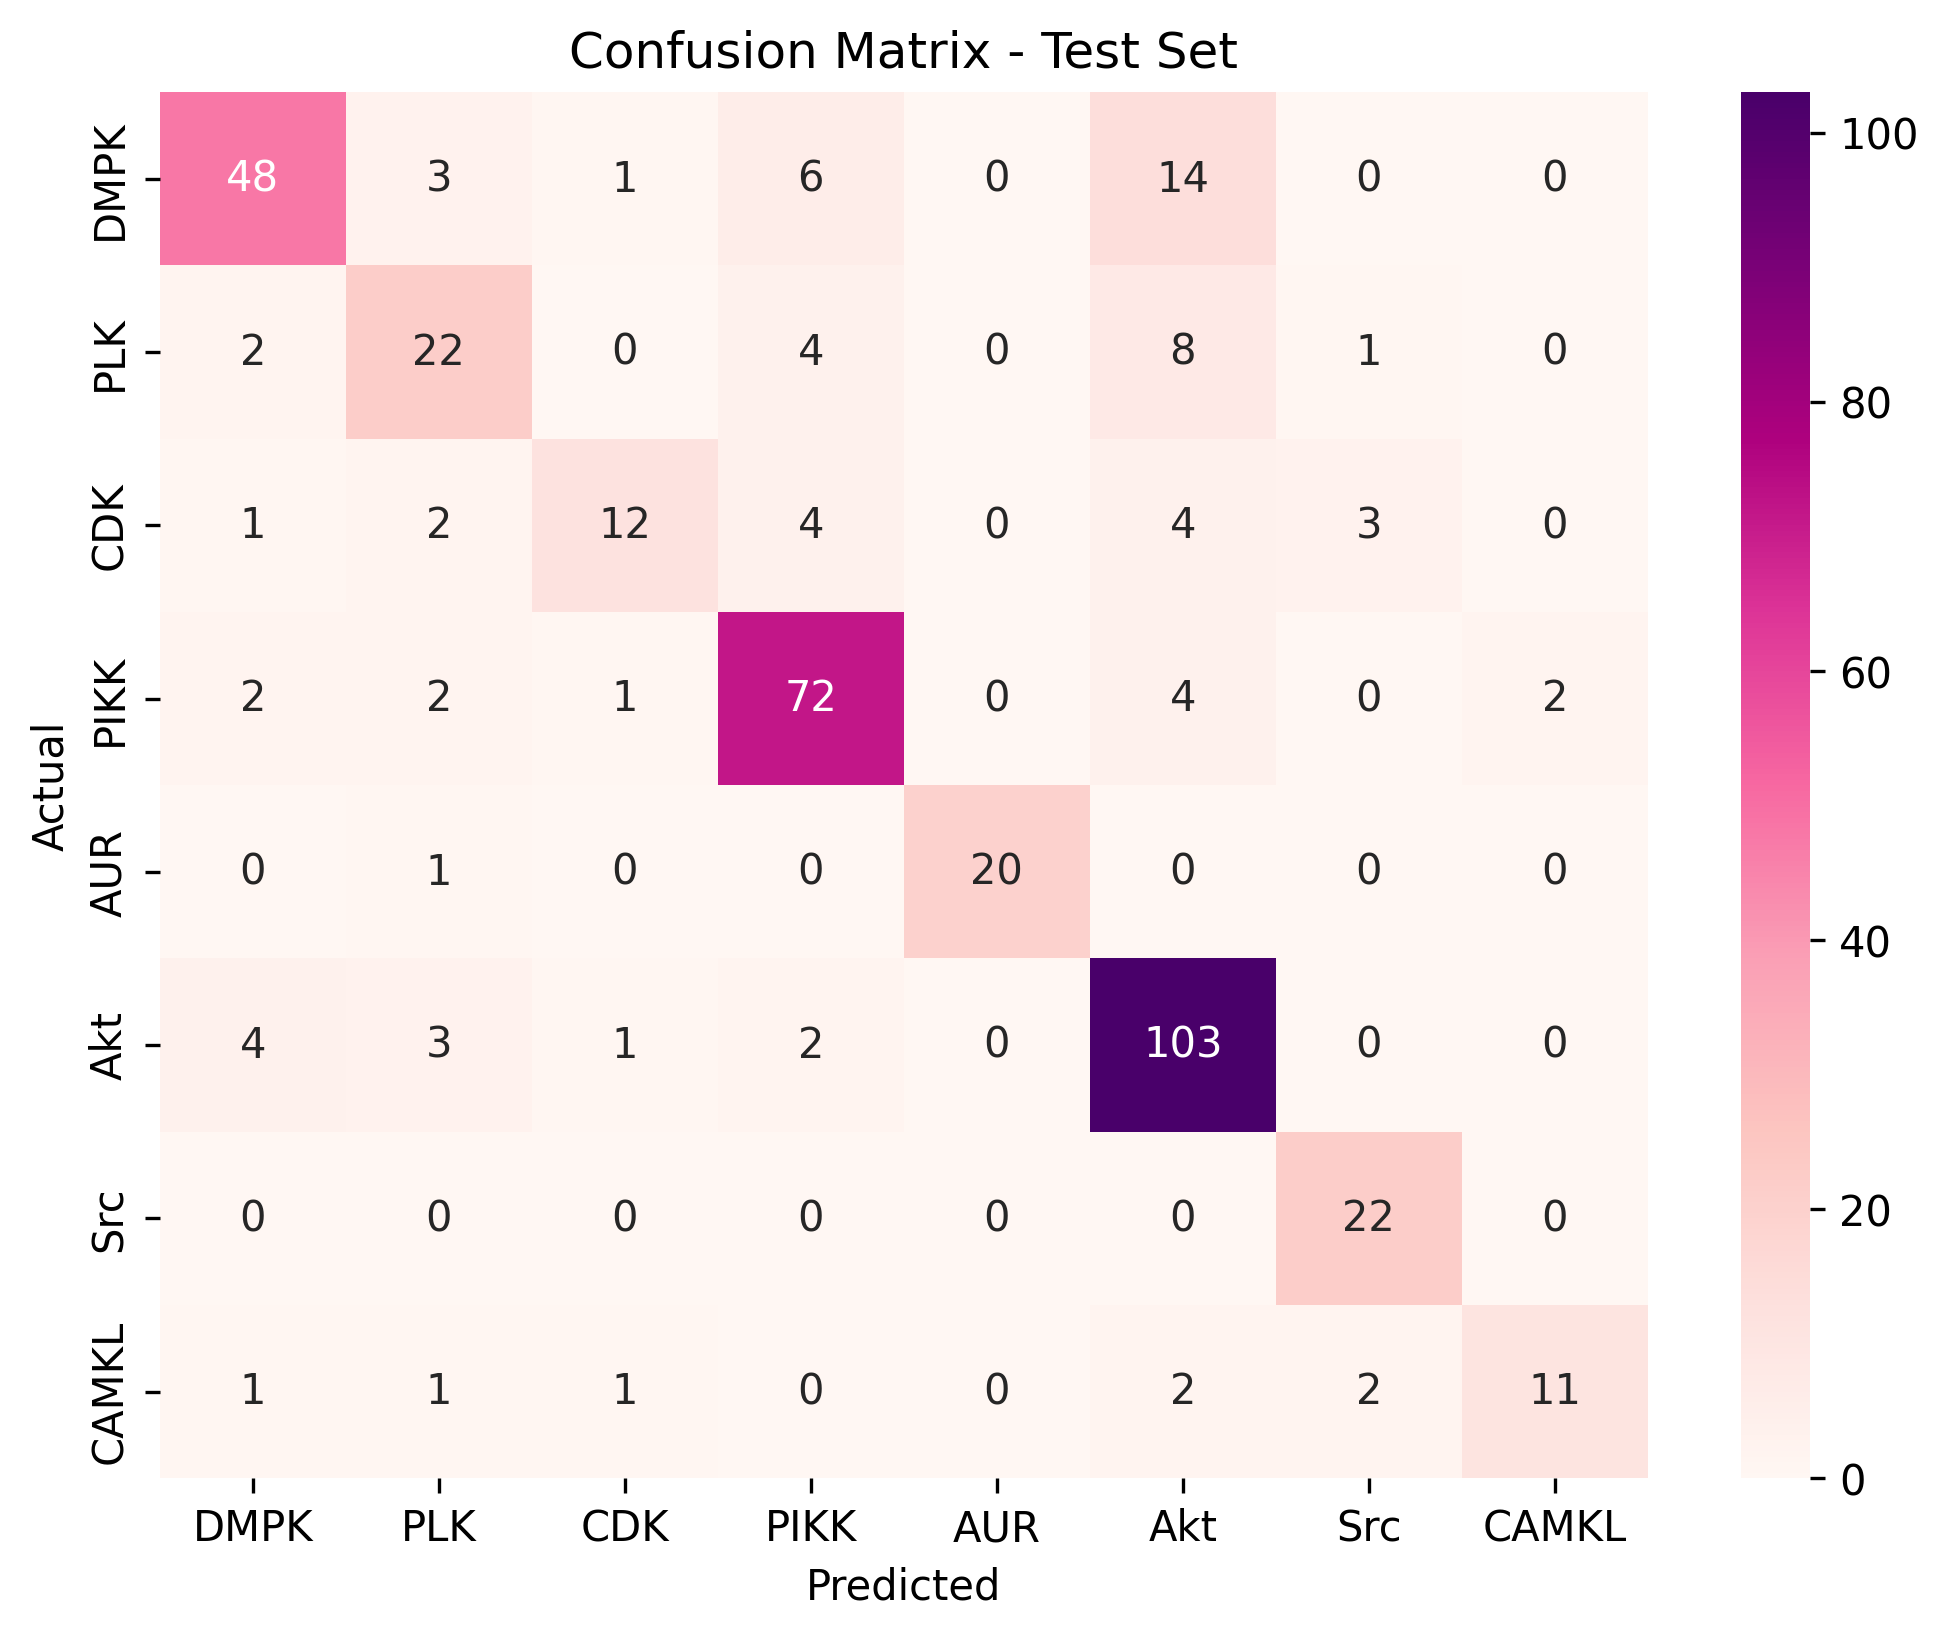

In [135]:
#  Confusion Matrix for test set
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", xticklabels=y.unique(), yticklabels=y.unique())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

In [134]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Split the data into training, calibration, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
# Print the shape of the splits to see how the data is divided
print("Training set shape:", X_train.shape, "Calibration set shape:", X_calib.shape, "Test set shape:", X_test.shape)

# 2. Train your SVM model
svm_model = SVC(probability=True)  # Use probability=True to get probabilities
svm_model.fit(X_train, y_train)

# Print the SVM model's parameters to ensure it's set up correctly
print("SVM model parameters:", svm_model.get_params())

# 3. Define non-conformity measure (e.g., Margin) that works with both calibration and test instances
def non_conformity_margin(model, X, y=None):
    # Use the model to get predicted probabilities
    probs = model.predict_proba(X)
    # Compute the margin for each instance: difference between the highest probability and the second highest
    margins = np.max(probs, axis=1) - np.partition(probs, -2)[:, -2]
    # Print the first few margins for inspection
    print("First few non-conformity margins:", margins[:5])
    return margins

# 4. Compute non-conformity scores for the calibration set
calib_scores = non_conformity_margin(svm_model, X_calib, y_calib)
# Print the first few calibration scores to inspect the values
print("First few calibration scores:", calib_scores[:5])

# 5. Compute non-conformity score for the test instance (single prediction)
def conformal_prediction(model, X_train, X_calib, y_calib, test_instance, alpha=0.05):
    calib_scores = non_conformity_margin(model, X_calib, y_calib)
    
    # Convert test_instance to numpy array and reshape it, but also retain feature names
    test_instance = test_instance.to_frame().T  # Convert to DataFrame (T transposes it)
    
    # Print the shape of the test_instance after conversion
    print("Test instance shape:", test_instance.shape)
    
    # Now compute non-conformity score for the test_instance separately
    test_score = non_conformity_margin(model, test_instance)  # Only pass the test instance here
    
    # Print the test score to see what it looks like
    print("Test instance non-conformity score:", test_score)
    
    # Compute the p-value (proportion of calibration scores greater than or equal to test_score)
    p_value = np.mean(calib_scores >= test_score)
    
    # Print the computed p-value
    print("p-value:", p_value)
    
    # Return the prediction set based on the confidence level (alpha)
    if p_value >= 1 - alpha:
        return "Accept Prediction"
    else:
        return "Reject Prediction"

# 6. Test the model on new data with CP
test_instance = X_test.iloc[0]  # Use .iloc[0] to get the first row as a test instance
print("Prediction result:", conformal_prediction(svm_model, X_train, X_calib, y_calib, test_instance))

Training set shape: (1827, 1419) Calibration set shape: (392, 1419) Test set shape: (392, 1419)
SVM model parameters: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
First few non-conformity margins: [0.89580436 0.94489522 0.32765507 0.87537102 0.3351175 ]
First few calibration scores: [0.89580436 0.94489522 0.32765507 0.87537102 0.3351175 ]
First few non-conformity margins: [0.89580436 0.94489522 0.32765507 0.87537102 0.3351175 ]
Test instance shape: (1, 1419)
First few non-conformity margins: [0.99783065]
Test instance non-conformity score: [0.99783065]
p-value: 0.007653061224489796
Prediction result: Reject Prediction


AttributeError: This 'SVC' has no attribute 'predict_proba'